# Data Cleaning, Exploratory Data Analysis, and Merging

This section is for cleaning, analyzing, and merging two tweet sentiment datasets.

In [67]:
# loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [130]:
# Loading datasets
df_provided = pd.read_csv('Data/Provided.csv', encoding='latin-1')
df_data2 = pd.read_csv('Data/Data2.csv', encoding='latin-1')


In [69]:
df_provided.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [70]:
df_provided.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


In [71]:
df_provided.shape

(9093, 3)

In [72]:
df_data2.head()

,id,date,text,target
0,0,2009-06-20,My concealer just broke!,0
1,1,2009-06-21,Mommy leaves soon,0
2,2,2009-06-03,@Boogaloo1 Not here it ain't! I've got an epi...,0
3,3,2009-06-16,I want my Blackberry back!!,0
4,4,2009-06-16,@Veganluke I can't even skype still dont have...,0


In [73]:
df_data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      10000 non-null  int64 
 1   date    10000 non-null  object
 2   text    10000 non-null  object
 3   target  10000 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 312.6+ KB


In [74]:
df_data2.shape

(10000, 4)

## Data Cleaning: Dataset 1 (Provided.csv)

Cleaning the first dataset by removing duplicates, handling missing values, and standardizing emotion labels.

In [75]:
df1 = df_provided.copy()

In [76]:
# Checking for missing values
df1.isnull().sum().sum()

5803

In [77]:
# Checking for duplicates
df1.duplicated().sum()

22

In [78]:
# Remove rows where tweet_text is missing
df1 = df1[df1['tweet_text'].notna()].copy()

In [79]:
# Clean text first
df1['tweet_text'] = df1['tweet_text'].str.strip()
df1['tweet_text_clean'] = df1['tweet_text'].str.lower()

In [80]:
# Remove duplicates based on tweet_text
df1 = df1.drop_duplicates(subset=['tweet_text']).copy()

In [81]:
# Handle missing categorical values
df1['emotion_in_tweet_is_directed_at'] = df1['emotion_in_tweet_is_directed_at'].fillna('Unknown')
df1['is_there_an_emotion_directed_at_a_brand_or_product'] = df1['is_there_an_emotion_directed_at_a_brand_or_product'].fillna('Unknown')


In [82]:
# Handle missing values in categorical columns
df1['emotion_in_tweet_is_directed_at'] = df1['emotion_in_tweet_is_directed_at'].fillna('Unknown')
df1['is_there_an_emotion_directed_at_a_brand_or_product'] = df1['is_there_an_emotion_directed_at_a_brand_or_product'].fillna('Unknown')


In [83]:
# Standardize emotion labels
emotion_mapping = {
    'Negative emotion': 'Negative',
    'Positive emotion': 'Positive',
    'No emotion toward brand or product': 'Neutral',
    "I can't tell": 'Uncertain',
    'Unknown': 'Unknown'
}

df1['is_there_an_emotion_directed_at_a_brand_or_product'] = (df1['is_there_an_emotion_directed_at_a_brand_or_product']
    .map(emotion_mapping).fillna('Unknown'))


In [84]:
# Add features
df1['dataset_source'] = 'Provided'
df1['text_length'] = df1['tweet_text'].str.len()
df1['word_count'] = df1['tweet_text'].str.split().str.len()

In [85]:
df1.shape

(9065, 7)

In [86]:
df1.isnull().sum().sum()

0

In [87]:
df1.duplicated(subset=['tweet_text']).sum()

0

## Data Cleaning: Dataset 2 (Data2.csv)

Cleaning the second dataset by removing duplicates, handling missing values, and standardizing sentiment labels.

In [88]:
df2 = df_data2.copy()

In [89]:
df2.isnull().sum().sum()

0

In [90]:
df2.duplicated().sum()

0

In [91]:
# Remove missing text
df2 = df2[df2['text'].notna()].copy()

In [92]:
# Clean text
df2['text'] = df2['text'].str.strip()
df2['text_clean'] = df2['text'].str.lower()

In [93]:
# Remove duplicates
df2 = df2.drop_duplicates(subset=['text_clean']).copy()

In [94]:
# Convert date
df2['date'] = pd.to_datetime(df2['date'], errors='coerce')

In [95]:
# 5. Map sentiment
sentiment_mapping = {
    0: 'Negative',
    1: 'Positive'
}
df2['sentiment'] = df2['target'].map(sentiment_mapping).fillna('Unknown')

In [96]:
# 6. Rename columns 
df2 = df2.rename(columns={'text': 'tweet_text', 'date': 'tweet_date'})

In [97]:
# 7. Add features
df2['dataset_source'] = 'Data2'
df2['text_length'] = df2['tweet_text'].str.len()
df2['word_count'] = df2['tweet_text'].str.split().str.len()

In [98]:
df2.shape

(9991, 9)

In [99]:
df2.isnull().sum().sum()

0

In [100]:
df2.duplicated(subset=['text_clean']).sum()

0

## Exploratory Data Analysis

Examining the distributions, patterns, and statistics of both cleaned datasets.

### Analysis: Dataset 1 (Brand-Specific Emotions)

Statistical summary and distribution analysis of the Provided.csv dataset with focus on brand emotions and sentiment.

In [101]:
df1.dtypes

tweet_text                                            object
emotion_in_tweet_is_directed_at                       object
is_there_an_emotion_directed_at_a_brand_or_product    object
tweet_text_clean                                      object
dataset_source                                        object
text_length                                            int64
word_count                                             int64
dtype: object

In [102]:
# Sentiment
if 'is_there_an_emotion_directed_at_a_brand_or_product' in df1.columns:
    print(df1['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts())

is_there_an_emotion_directed_at_a_brand_or_product
Neutral      5372
Positive     2968
Negative      569
Uncertain     156
Name: count, dtype: int64


In [103]:
# Brand
if 'emotion_in_tweet_is_directed_at' in df1.columns:
    print(df1['emotion_in_tweet_is_directed_at'].value_counts().head(10))

emotion_in_tweet_is_directed_at
Unknown                            5785
iPad                                943
Apple                               659
iPad or iPhone App                  469
Google                              428
iPhone                              296
Other Google product or service     293
Android App                          80
Android                              77
Other Apple product or service       35
Name: count, dtype: int64


In [104]:
df1['text_length'].mean()

104.96933259790403

In [105]:
df1['text_length'].median()

109.0

In [106]:
df1['text_length'].min()

11

In [107]:
df1['text_length'].max()

178

### Analysis: Dataset 2 (General Sentiment)

Statistical summary and distribution analysis of the Data2.csv dataset with focus on general sentiment classification.

In [108]:
df2.dtypes

id                         int64
tweet_date        datetime64[ns]
tweet_text                object
target                     int64
text_clean                object
sentiment                 object
dataset_source            object
text_length                int64
word_count                 int64
dtype: object

In [109]:
df2['sentiment'].value_counts()

sentiment
Positive    4996
Negative    4995
Name: count, dtype: int64

In [110]:
df2['tweet_date'].min()

Timestamp('2009-04-06 00:00:00')

In [111]:
df2['tweet_date'].max()

Timestamp('2009-06-25 00:00:00')

In [112]:
df2['tweet_date'].isna().sum()

0

In [113]:
# Text stats
print(f"\nText Length Statistics:")
print(f"  Mean: {df2['text_length'].mean():.0f} chars")
print(f"  Median: {df2['text_length'].median():.0f} chars")
print(f"  Min: {df2['text_length'].min()} chars")
print(f"  Max: {df2['text_length'].max()} chars")


Text Length Statistics:
  Mean: 74 chars
  Median: 69 chars
  Min: 7 chars
  Max: 327 chars


## Merging Datasets

Standardizing column names and combining both datasets into a single unified dataset. The merged dataset consolidates all records while maintaining data integrity and adding source tracking information.

In [114]:
# Standardize Dataset 1

df1_merged = df1.copy()

# Rename for consistency
df1_merged = df1_merged.rename(columns={
    'tweet_text': 'text',
    'is_there_an_emotion_directed_at_a_brand_or_product': 'sentiment',
    'emotion_in_tweet_is_directed_at': 'target_brand',
    'dataset_source': 'source'
})

# Keep only needed columns 
cols_df1 = ['text', 'sentiment', 'target_brand', 'source', 'text_length', 'word_count']
df1_merged = df1_merged[[col for col in cols_df1 if col in df1_merged.columns]].copy()

# Add missing columns
df1_merged['tweet_id'] = pd.RangeIndex(start=1, stop=len(df1_merged)+1)
df1_merged['date'] = pd.NaT
df1_merged['sentiment_source'] = 'Brand-Specific'

In [115]:
# Standardize Dataset 2

df2_merged = df2.copy()

# Rename for consistency
df2_merged = df2_merged.rename(columns={
    'tweet_text': 'text',
    'tweet_date': 'date',
    'dataset_source': 'source'
})

# Keep only needed columns 
cols_df2 = ['text', 'sentiment', 'id', 'date', 'source', 'text_length', 'word_count']
df2_merged = df2_merged[[col for col in cols_df2 if col in df2_merged.columns]].copy()

# Rename id → tweet_id (if exists)
if 'id' in df2_merged.columns:
    df2_merged = df2_merged.rename(columns={'id': 'tweet_id'})
else:
    df2_merged['tweet_id'] = pd.RangeIndex(start=100000, stop=100000+len(df2_merged))

# Add missing columns
df2_merged['target_brand'] = 'General'
df2_merged['sentiment_source'] = 'General'


In [116]:
# Align Column Order

common_cols = [
    'text', 'sentiment', 'sentiment_source', 'target_brand',
    'source', 'text_length', 'word_count', 'tweet_id', 'date'
]

df1_final = df1_merged.reindex(columns=common_cols)
df2_final = df2_merged.reindex(columns=common_cols)

In [117]:
# Merge Datasets

merged_df = pd.concat([df1_final, df2_final], ignore_index=True)

In [118]:
# Remove duplicates (case-insensitive)
merged_df['text_clean'] = merged_df['text'].str.lower().str.strip()
merged_df = merged_df.drop_duplicates(subset=['text_clean']).copy()

In [119]:
# Total rows and columns
print(f" Total rows: {len(merged_df):,}")
print(f" Total columns: {merged_df.shape[1]}")

 Total rows: 19,038
 Total columns: 10


In [120]:
# Dataset breakdown
print(merged_df['source'].value_counts())

source
Data2       9991
Provided    9047
Name: count, dtype: int64


In [121]:
# Sentiment distribution
print(merged_df['sentiment'].value_counts())

sentiment
Positive     7961
Negative     5564
Neutral      5357
Uncertain     156
Name: count, dtype: int64


In [122]:
# Sentiment source
print(merged_df['sentiment_source'].value_counts())

sentiment_source
General           9991
Brand-Specific    9047
Name: count, dtype: int64


In [123]:
# Missing values
print(merged_df.isnull().sum())

text                   0
sentiment              0
sentiment_source       0
target_brand           0
source                 0
text_length            0
word_count             0
tweet_id               0
date                9047
text_clean             0
dtype: int64


In [124]:
# Duplicates
print(merged_df.duplicated(subset=['text_clean']).sum())

0


## Visualizations

Creating comprehensive visualizations to compare sentiment distribution, text lengths, and data sources.

### Visual 1 : Sentiment Distribution (Bar Chart)

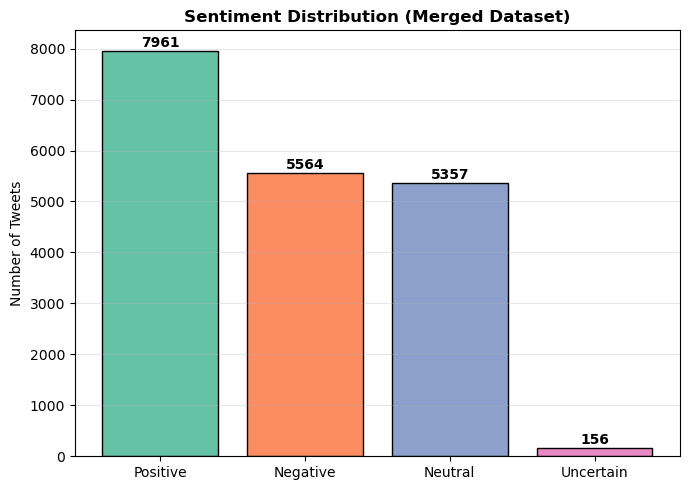

In [125]:
plt.figure(figsize=(7, 5))

sentiment_counts = merged_df['sentiment'].value_counts()
colors = plt.cm.Set2.colors[:len(sentiment_counts)]

plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='black')

plt.title('Sentiment Distribution (Merged Dataset)', fontweight='bold')
plt.ylabel('Number of Tweets')
plt.grid(axis='y', alpha=0.3)

# Labels
offset = max(sentiment_counts.values) * 0.01
for i, val in enumerate(sentiment_counts.values):
    plt.text(i, val + offset, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Visual 2 : Source Distribution (Pie Chart)

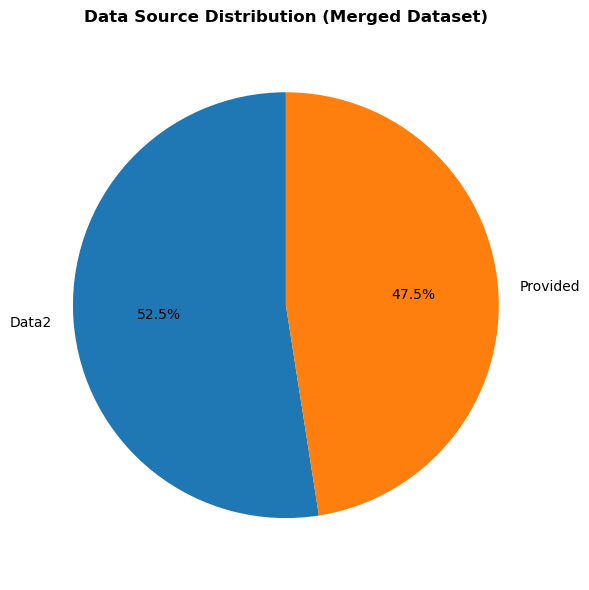

In [126]:
plt.figure(figsize=(6, 6), facecolor='white')  

source_counts = merged_df['source'].value_counts()

plt.pie(source_counts.values,labels=source_counts.index,autopct='%1.1f%%',startangle=90)

plt.title('Data Source Distribution (Merged Dataset)', fontweight='bold')

plt.gca().set_facecolor('white')  
plt.axis('equal')

plt.tight_layout()
plt.show()

### Visual 3 : Text Length Distribution (Histogram)

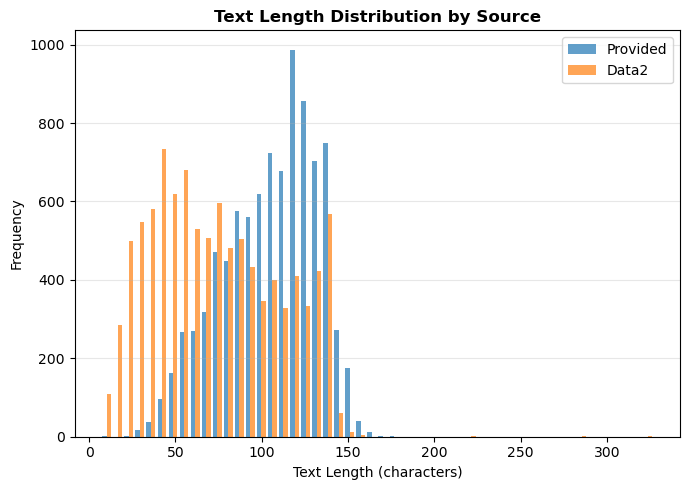

In [127]:
plt.figure(figsize=(7, 5))

provided_lengths = merged_df.loc[merged_df['source'] == 'Provided', 'text_length'].dropna()
data2_lengths = merged_df.loc[merged_df['source'] == 'Data2', 'text_length'].dropna()

plt.hist([provided_lengths, data2_lengths],bins=50,label=['Provided', 'Data2'],alpha=0.7)

plt.title('Text Length Distribution by Source', fontweight='bold')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Visual 4 : Sentiment by Source (Grouped Bar Chart)

<Figure size 700x500 with 0 Axes>

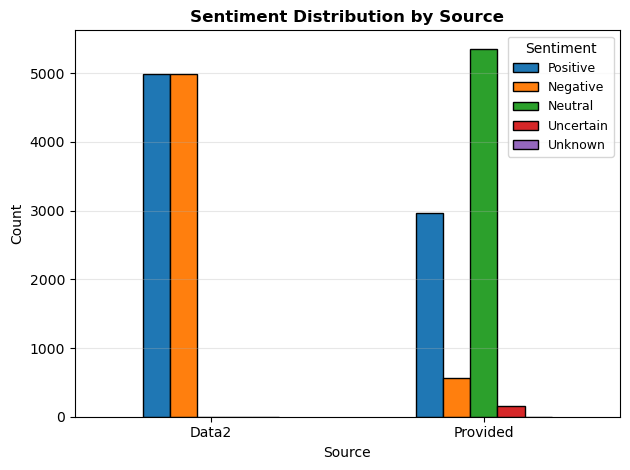

In [128]:
plt.figure(figsize=(7, 5))

sentiment_order = ['Positive', 'Negative', 'Neutral', 'Uncertain', 'Unknown']

sentiment_by_source = pd.crosstab(merged_df['source'], merged_df['sentiment']).reindex(columns=sentiment_order, fill_value=0)

sentiment_by_source.plot(kind='bar', edgecolor='black')

plt.title('Sentiment Distribution by Source', fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Source')
plt.legend(title='Sentiment', fontsize=9)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Export Merged Dataset

Saving the cleaned and merged dataset to CSV format for downstream analysis and machine learning tasks.

In [129]:
output_filename = 'Merged_Clean_Dataset.csv'
merged_df.to_csv(output_filename, index=False, encoding='utf-8')

# Confirm save
print(f" Dataset successfully saved as: {output_filename}")
print(f" Rows: {len(merged_df):,} | Columns: {merged_df.shape[1]}")


 Dataset successfully saved as: Merged_Clean_Dataset.csv
 Rows: 19,038 | Columns: 10


### Machine Learning Modeling ###


This section we build and evaluate five NLP models on the merged dataset.

Our strategy is we move from simple baseline model  to gradient boosting then explainability
Its devided into five phases

| Phase | Model | Package | Task |
|---|---|---|---|
| 1 | VADER | nltk | Rule-based baseline (no training) |
| 2 | Naive Bayes | sklearn | Binary classifier (Pos vs Neg) |
| 3 | Logistic Regression | sklearn | Multiclass (Pos / Neg / Neutral) |
| 4 | XGBoost | xgboost | Multiclass — gradient boosting |
| 5 | LightGBM | lightgbm | Multiclass — faster boosting |
| 6 | SHAP | shap | Global + local explainability |

**Primary metric:** Recall on the Negative class (catching negative tweets = top priority)
**Secondary metric:** Macro F1-score (balanced performance across all classes)


## Importing Modelling Libraries

In [ ]:
# NLP 
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
for pkg in ['punkt','punkt_tab','stopwords','vader_lexicon','wordnet']:
    nltk.download(pkg, quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score)
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score, recall_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

#  Gradient Boosting 
import xgboost as xgb
import lightgbm as lgb

# Explainability
import shap

import sklearn
print("All modeling libraries loaded")
print(f"   sklearn   {sklearn.__version__}")
print(f"   xgboost   {xgb.__version__}")
print(f"   lightgbm  {lgb.__version__}")
print(f"   shap      {shap.__version__}")

All modeling libraries loaded
   sklearn   1.8.0
   xgboost   3.2.0
   lightgbm  4.6.0
   shap      0.51.0


## Data Preparation

In [136]:
# ── Use merged_df from the data prep section ─────────────────────────────
# Keep only the three core sentiment classes for modeling
# Uncertain / Unknown carry no reliable label signal
df_model = merged_df[merged_df['sentiment'].isin(['Positive','Negative','Neutral'])].copy()
df_model = df_model.dropna(subset=['text']).copy()
df_model['text'] = df_model['text'].astype(str)

print(f"Modeling dataset: {len(df_model):,} tweets")
print(f"\nClass distribution:")
print(df_model['sentiment'].value_counts())
print(f"\nDropped (Uncertain/Unknown): {len(merged_df) - len(df_model):,} tweets")

Modeling dataset: 18,882 tweets

Class distribution:
sentiment
Positive    7961
Negative    5564
Neutral     5357
Name: count, dtype: int64

Dropped (Uncertain/Unknown): 156 tweets


In [137]:
# ── Text preprocessing ───────────────────────────────────────────────────
STOP = set(stopwords.words('english'))
STOP -= {'not', 'no', 'never', 'nor', "n't"}   # keep negation — critical for sentiment
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)     # remove URLs
    text = re.sub(r'@\w+', '', text)                   # remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)             # hashtag → word
    text = re.sub(r'[^a-z\s]', ' ', text)             # remove punctuation
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing tweets (this may take a moment)...")
df_model['clean_text'] = df_model['text'].apply(preprocess)
print(f"✅ Done — {len(df_model):,} tweets preprocessed")

# Before/after examples
print("\n--- Before/After Examples ---")
for _, row in df_model.sample(3, random_state=42).iterrows():
    print(f"  ORIGINAL : {row['text'][:80]}")
    print(f"  CLEANED  : {row['clean_text'][:80]}")
    print(f"  SENTIMENT: {row['sentiment']}\n")


Preprocessing tweets (this may take a moment)...
✅ Done — 18,882 tweets preprocessed

--- Before/After Examples ---
  ORIGINAL : At #SXSW? D/L @mention 4 iPhone &amp; come to the UJ* booth in ACC hall 2! Snap 
  CLEANED  : sxsw iphone amp come booth acc hall snap pic amp send fightthepaddle link
  SENTIMENT: Neutral

  ORIGINAL : Unlike Google Analytics, this is meant to show to others and has sharing capabil
  CLEANED  : unlike google analytics meant show others sharing capability sxsw bavcid
  SENTIMENT: Neutral

  ORIGINAL : Mashable! - The iPad 2 Takes Over SXSW [VIDEO] #ipad #sxsw #gadgets {link}
  CLEANED  : mashable ipad take sxsw video ipad sxsw gadget link
  SENTIMENT: Neutral



In [ ]:
# ── Encode labels & split ─────────────────────────────────────────────────
le = LabelEncoder()
df_model['label'] = le.fit_transform(df_model['sentiment'])
label_names = le.classes_
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X = df_model['clean_text']
y = df_model['label']

# Stratified 80/20 split — preserves class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")
print("\nClass proportions (stratification check):")
for name, y_s in [("Full", y), ("Train", y_train), ("Test", y_test)]:
    props = y_s.value_counts(normalize=True).sort_index()
    row = {label_names[i]: f"{props.get(i,0)*100:.1f}%" for i in range(len(label_names))}
    print(f"  {name:<6}: {row}")


In [ ]:
# ── Feature extraction ────────────────────────────────────────────────────

# TF-IDF — main feature extractor for gradient boosting models
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=2,
    sublinear_tf=True       # log normalisation for long tweets
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# CountVectorizer — for Naive Bayes (requires non-negative counts)
cv = CountVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
X_train_cv = cv.fit_transform(X_train)
X_test_cv  = cv.transform(X_test)

print(f"TF-IDF matrix : {X_train_tfidf.shape}")
print(f"CountVect matrix: {X_train_cv.shape}")
print("Feature extraction complete")
